# Credit Card Fraud Detection

## 📦 Dataset
> Download `creditcard.csv` from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and place it in the root folder.

| Property | Detail |
|---|---|
| Total Records | 284,807 |
| Fraudulent | 492 (~0.17%) |
| Features | V1–V28 (PCA) + Amount + Class |

# Objective
- The goal of this project is to detect fraudulent credit card transactions using advanced machine learning models and reduce financial fraud risks.
- In this project we will : start from understanding the data preprocess it and EDA 
- Train multiple ML models : Random Forest, XGBoost, Lightgbm, Catboost
- Handling class imbalance
- Evaluating useful metrices and confusion matrix
- Using SHAP for model explainability
- Deploying the best-performing model

In [1]:
## 🔧 Libraries & Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# Loading Dataset
df= pd.read_csv('creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Checking Missing Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

> After we did the EDA we will remove the time column from our data as it will not be useful when we do the model training

Our Dataset is clean Already Perfect for furthur Analysis.

## Feature scaling

In [8]:
# Feature Scaling "Amount"
import os 
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
print(f"Amount scaled successfully. Shape: {df.shape}")

Amount scaled successfully. Shape: (284807, 31)


In [9]:
df['Hour'] = (df['Time'] / 3600) % 24


- Raw second start from the very first transaction, which then converte into hours by dividing from 3600 after that we added and the modulo operator — gives remainder after dividing by 24. This wraps hours back into a 0-23 clock format.

In [10]:
df.describe(include='float')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,0.927124,14.537951
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,3.495006,5.847061
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,-0.307413,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,-0.229162,10.598194
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,0.000000,15.010833
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,0.770838,19.329722
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,358.683155,23.999444


## Exploratory Data Analysis (Basic plots)

Class Imbalance Check :-

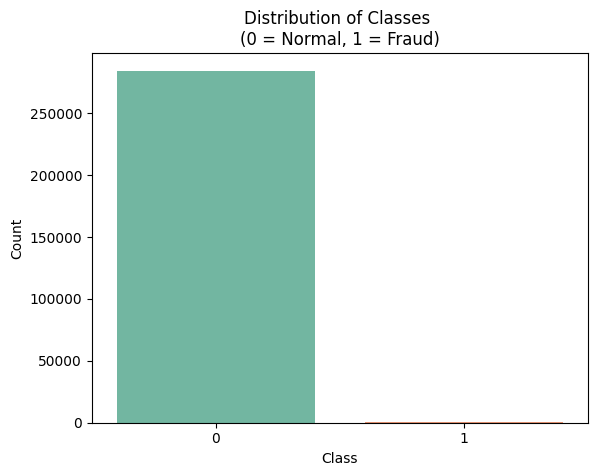

In [11]:
sns.countplot(x ='Class',data = df,  palette= 'Set2')
plt.title("Distribution of Classes \n(0 = Normal, 1 = Fraud)")
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Here it can be seen that Distribution of fraud is very low as compared to Normal.

## Transaction Amount Distribution:-

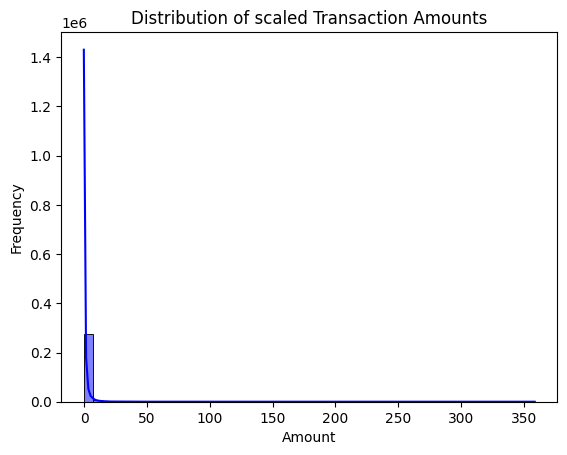

In [12]:
sns.histplot(df['Amount'], bins = 50, kde = True, color = 'blue')
plt.title('Distribution of scaled Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

This long Tail Transaction shows that a very large number of small transaction and fewer larger ones. Most Transaction Amount are concentrated at the lower end of scale.

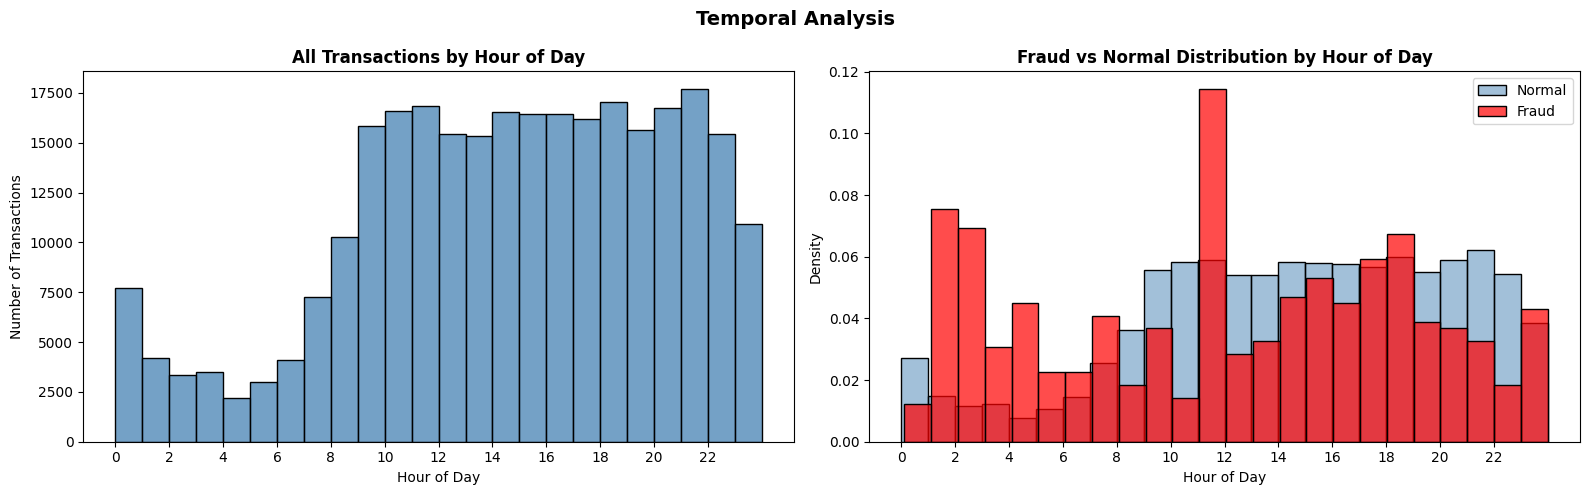

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# All transactions by hour
sns.histplot(data=df, x="Hour", bins=24, color='steelblue', ax=axes[0])
axes[0].set_title('All Transactions by Hour of Day', weight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 24, 2))

# Fraud vs Normal by hour 
sns.histplot(data=df[df['Class']==0], x="Hour", bins=24, stat='density',
             color='steelblue', alpha=0.5, label='Normal', ax=axes[1])
sns.histplot(data=df[df['Class']==1], x="Hour", bins=24, stat='density',
             color='red', alpha=0.7, label='Fraud', ax=axes[1])
axes[1].set_title('Fraud vs Normal Distribution by Hour of Day', weight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Density')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.suptitle('Temporal Analysis', weight='bold', fontsize=14)
plt.tight_layout()
plt.show()

- Left plot (All transactions) :

Transactions drop significantly between 2am - 7am (people sleeping)
Peak activity from 10am - 10pm
Normal human behavior pattern

- Right plot (Fraud vs Normal density):

Fraud spikes heavily at 1am - 2am and 11am - 12pm
The 1-2am spike is classic — low transaction volume but high fraud rate, fraudsters exploit the quiet period
Normal transactions are spread evenly across the day.

Amount vs Fraud

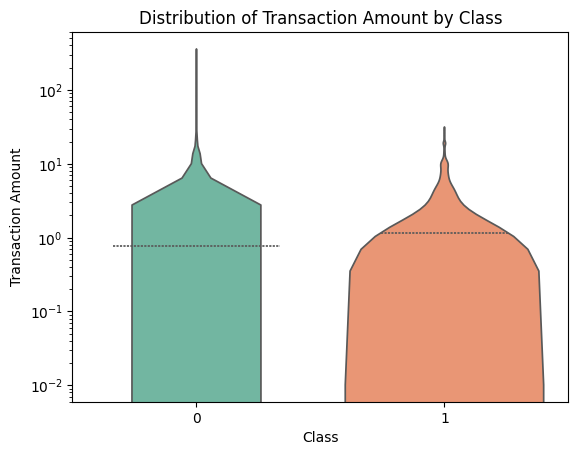

In [14]:
sns.violinplot(x = 'Class', y = 'Amount', data = df, palette='Set2', scale='count', inner='quartile')
plt.title("Distribution of Transaction Amount by Class")
plt.xlabel('Class')
plt.ylabel('Transaction Amount')
plt.yscale('log') # To Handle Outliers
plt.show()

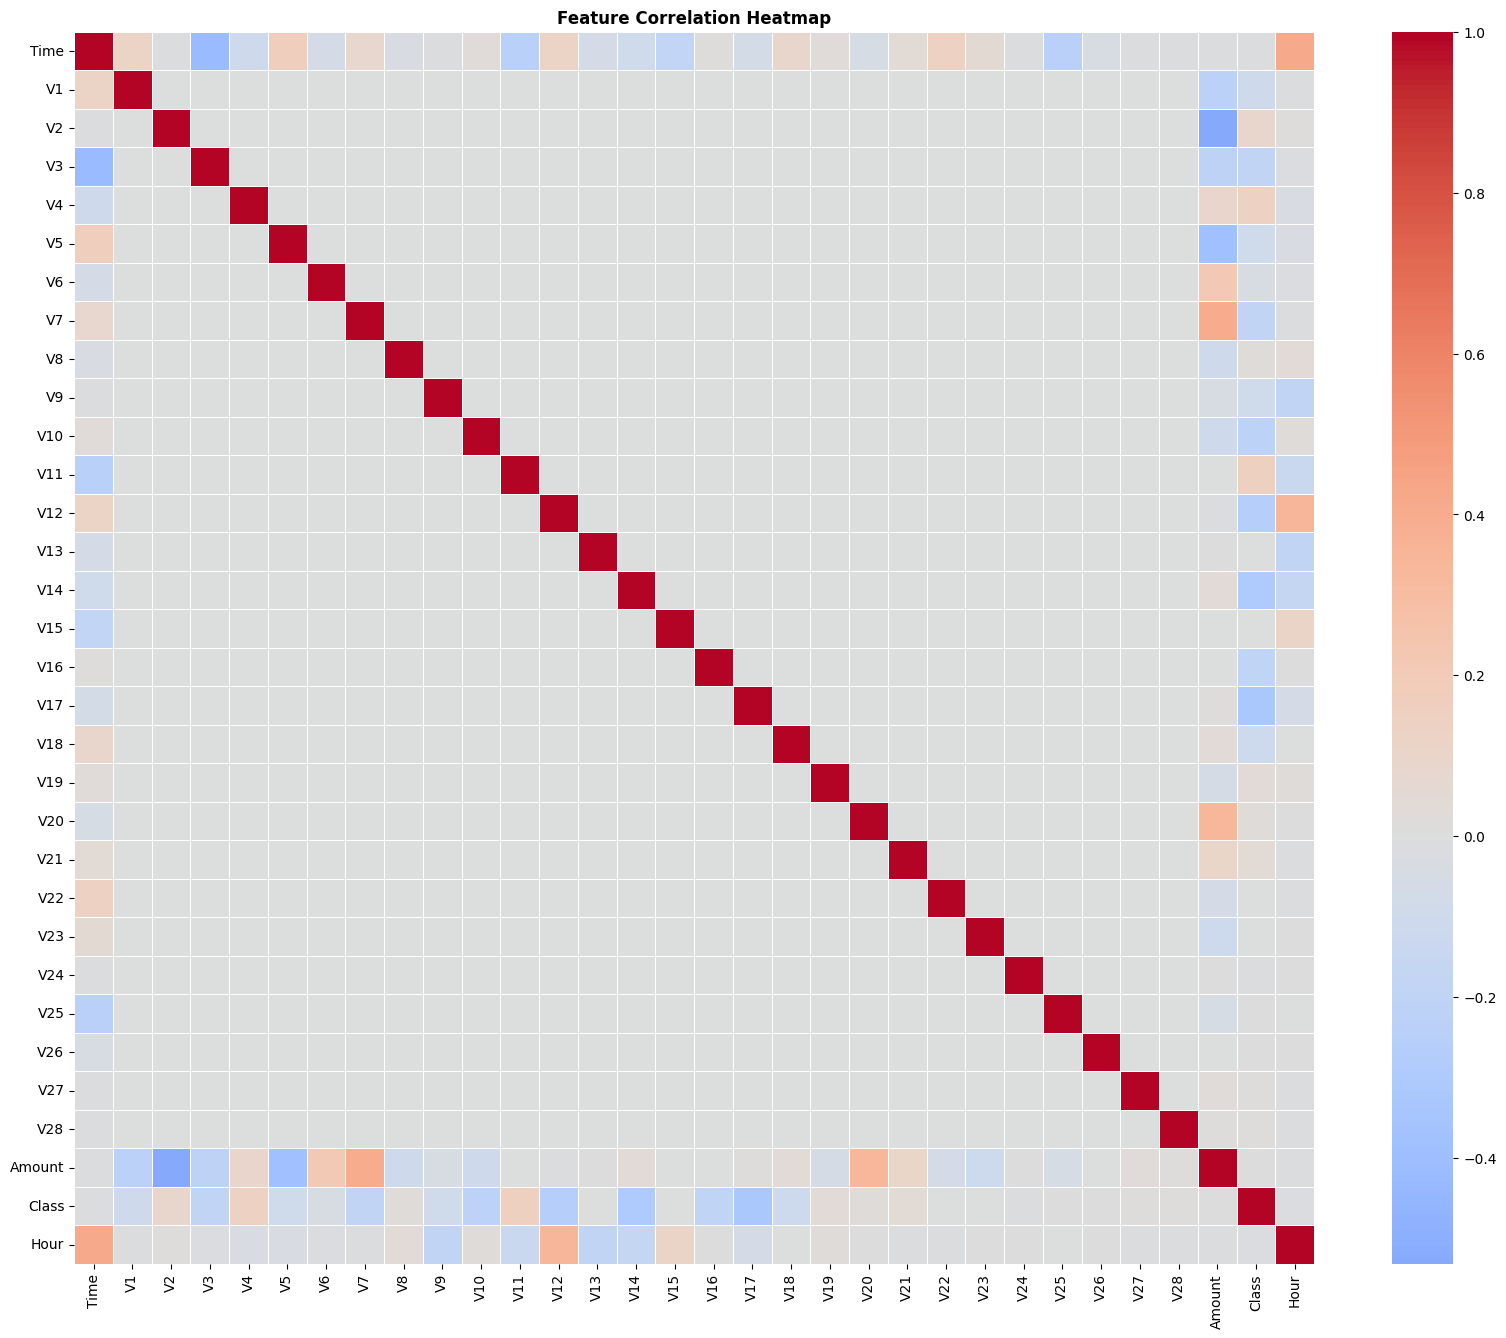

In [15]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap", weight='bold')
plt.show()

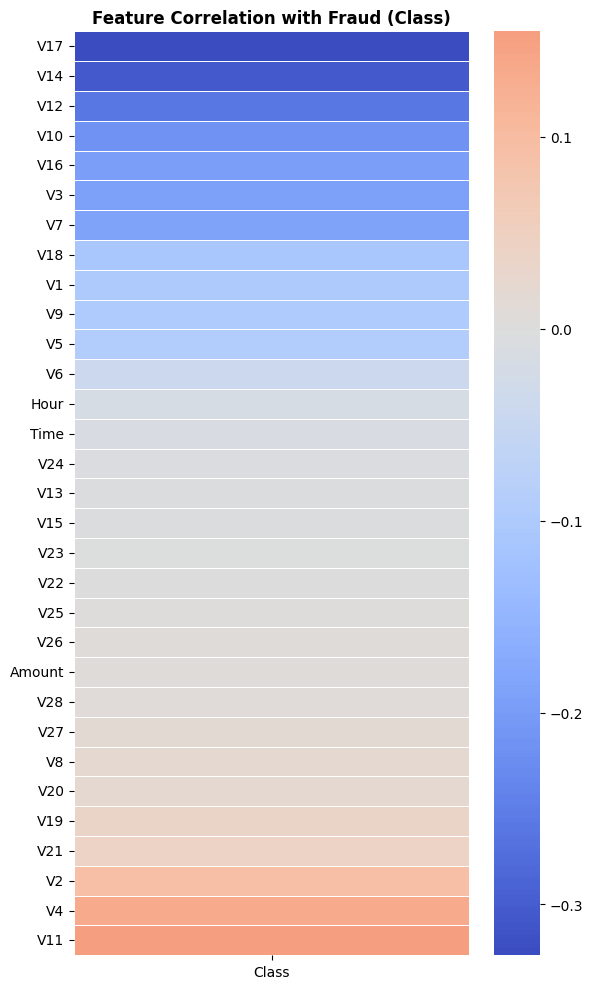

In [16]:
class_corr = df.corr()[['Class']].drop('Class').sort_values('Class')

plt.figure(figsize=(6, 10))
sns.heatmap(class_corr, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, cbar=True)
plt.title("Feature Correlation with Fraud (Class)", weight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap — What It Shows

- The first thing that stands out is that V1 through V28 are essentially 
uncorrelated with each other — the heatmap is almost entirely grey except 
for the diagonal. This is expected since these are PCA components, which 
are mathematically designed to be independent.

- The interesting part is the Class column. V14, V17, V12 and V10 show 
negative correlation with fraud while V4 and V11 lean positive correlation — 
which we see in the bar chart
.

- Amount again shows near zero correlation, which keeps coming up across 
every plot we've done so far. It's becoming clear that transaction amount 
is simply not a reliable fraud signal in this dataset.

- Since none of the V features are correlated with each other, our models 
are getting 28 uniquely different pieces of information — not the same 
thing repeated in different ways. More unique signals = better chance of 
catching fraud patterns.

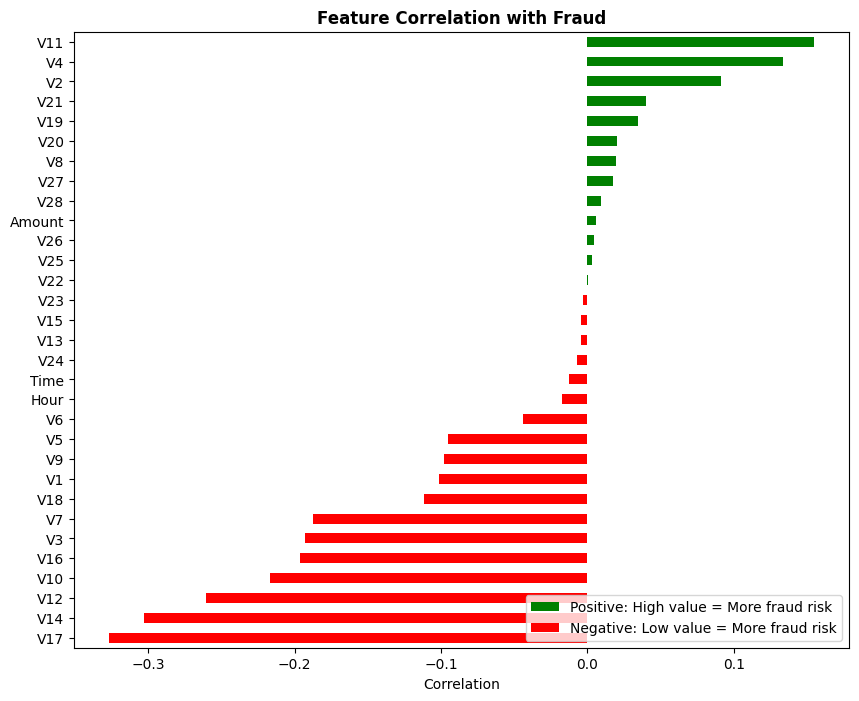

In [17]:
corr_with_fraud = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10,8))
corr_with_fraud.plot(kind='barh', color=['red' if x < 0 else 'green' 
                                          for x in corr_with_fraud])
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Positive: High value = More fraud risk'),
    Patch(facecolor='red',   label='Negative: Low value = More fraud risk')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.title("Feature Correlation with Fraud", weight='bold')
plt.xlabel("Correlation")
plt.show()

### Feature Correlation with Fraud — What It Tells Us :-
- Looking at how each feature correlates with the Class column gives us 
a good early signal of what the models will likely rely on.

- V17, V14 and V12 show the strongest negative correlation — meaning 
unusually low values in these features are a red flag for fraud. 
V11, V4 and V2 go the other way, higher values tend to appear more in 
fraudulent transactions.

- Amount sits almost at zero — it basically means that
knowing the transaction amount alone tells you almost nothing about
whether it's fraud or not. The real signal is buried in the V features.

- One thing to see — when we run SHAP after training and evaluation, if V17, V14, 
V12, V11, V4 and V2 show up as the most important features there too, 
it means our EDA and our model are telling the same story.

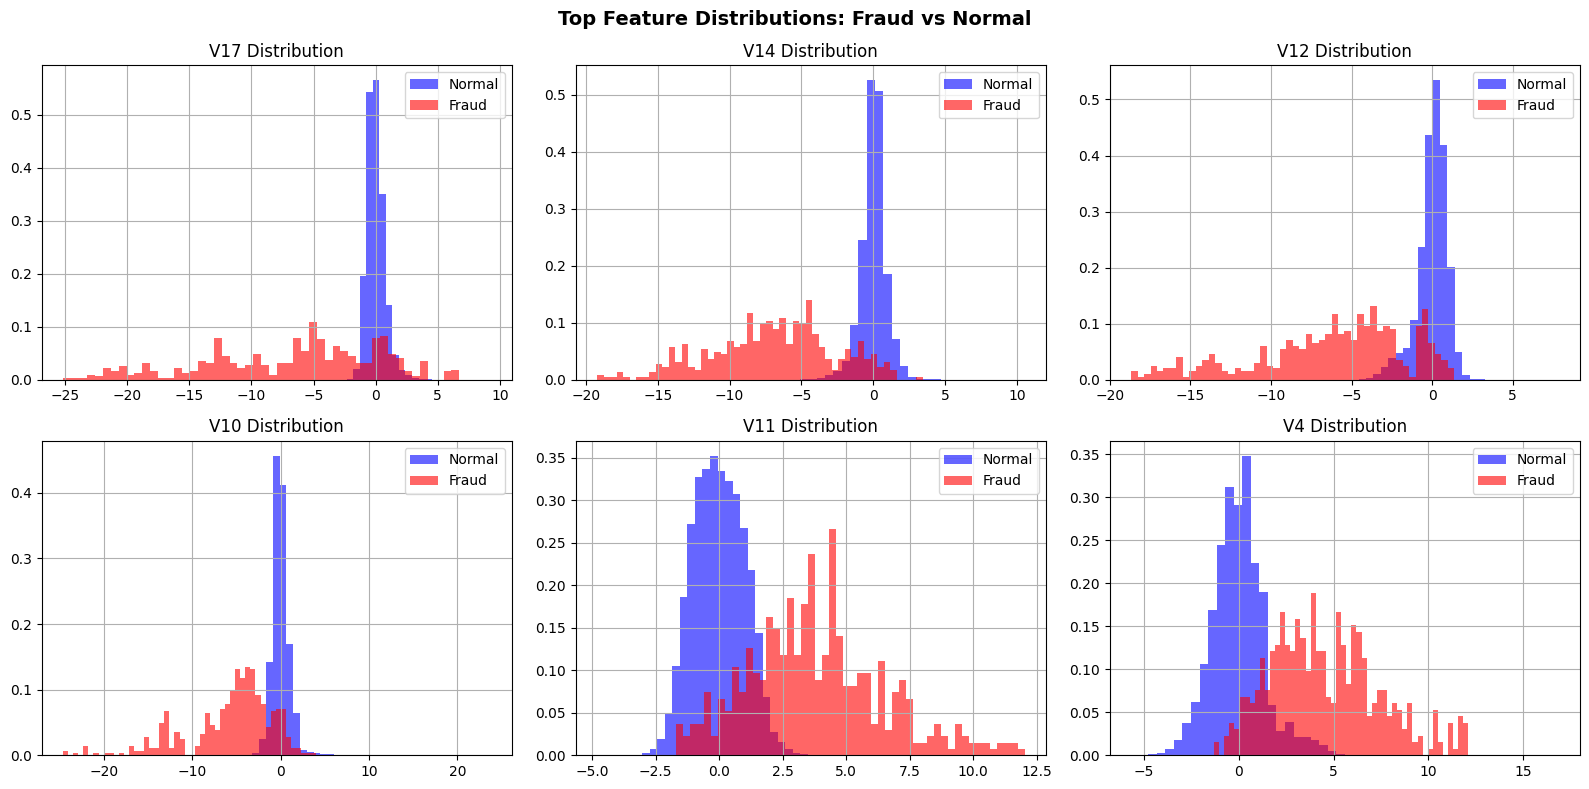

In [18]:
# Top features most correlated with fraud
top_features = ['V17', 'V14', 'V12', 'V10', 'V11', 'V4']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    df[df['Class']==0][feature].hist(ax=axes[i], bins=50, 
                                      alpha=0.6, label='Normal', color='blue', density = True)
    df[df['Class']==1][feature].hist(ax=axes[i], bins=50, 
                                      alpha=0.6, label='Fraud', color='red', density = True)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].legend()

plt.suptitle("Top Feature Distributions: Fraud vs Normal", 
             weight='bold', fontsize=14)
plt.tight_layout()
plt.show()

These six plots confirm what the correlation analysis suggested. 

For V17, V14, V12 and V10 — normal transactions cluster tightly 
around zero while fraud cases spread out towards the negative side. 
For V11 and V4 it's the opposite, fraud shifts noticeably to the right.

This kind of separation is exactly what tree-based models like 
Random Forest and XGBoost perfoms well during training.

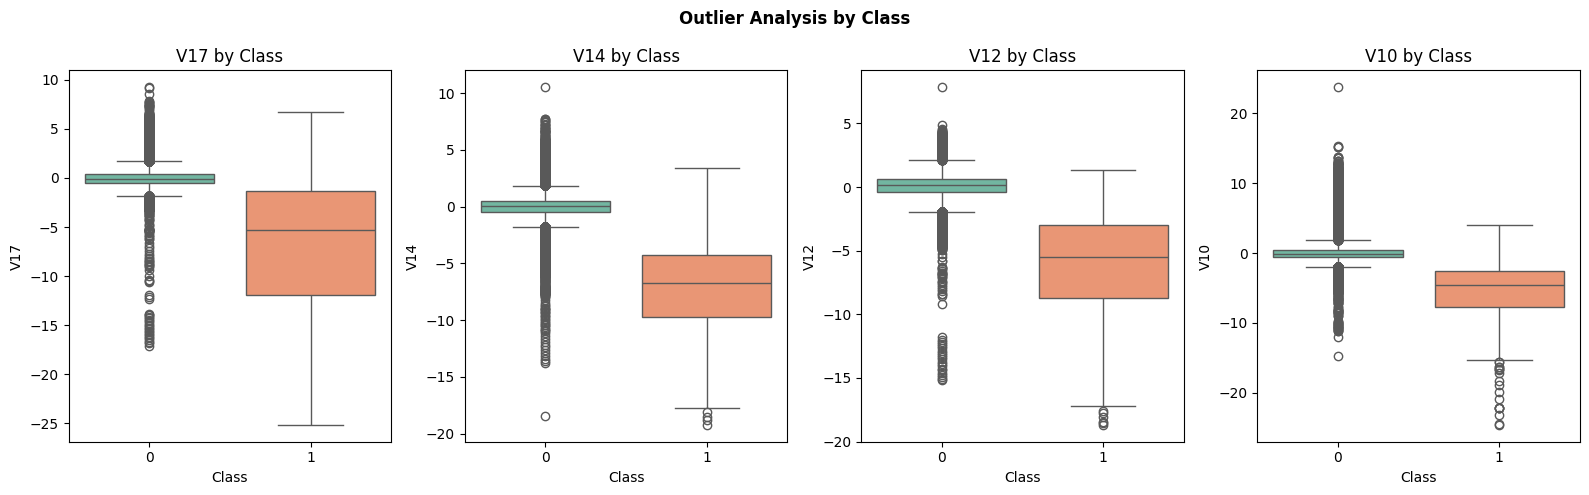

In [19]:
top_features = ['V17', 'V14', 'V12', 'V10']

fig, axes = plt.subplots(1, 4, figsize=(16,5))
for i, feature in enumerate(top_features):
    sns.boxplot(x='Class', y=feature, data=df, 
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feature} by Class')

plt.suptitle("Outlier Analysis by Class", weight='bold')
plt.tight_layout()
plt.show()

- We keep these outliers as they are — they are real transactions that 
actually happened. If we removed every transaction that looked 
statistically unusual, we'd be training our model on an unrealistically 
clean dataset. In the real world messy edge cases show up every day, 
so the model needs to have seen them before.

## Checking Imbalance

In [20]:
df['Class'].value_counts()
df['Class'].value_counts(normalize= True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Here 0 means a normal transaction and 1 means a fraudulent one.

99.82% of transactions in this dataset are legitimate which creates 
a tricky situation — a model that simply predicts "not fraud" for 
every single transaction would still be 99.82% accurate. That's 
why accuracy is a useless metric here and we will rely on Recall, 
F1-Score and ROC-AUC instead.

In [21]:
# Dropping time
df = df.drop('Time', axis=1)

> we dropped time here now because we will not need it later on our model training.

In [22]:
fraud_stats = df[df['Class']==1].describe()
normal_stats = df[df['Class']==0].describe()

# Just compare the means — most useful part
mean_comparison = pd.DataFrame({
    'Normal Mean': normal_stats.loc['mean'].round(3),
    'Fraud Mean': fraud_stats.loc['mean'].round(3),
    'Difference': (fraud_stats.loc['mean'] - normal_stats.loc['mean']).round(3)
}).drop('Class')

mean_comparison['Difference'] = mean_comparison['Difference'].abs()
mean_comparison = mean_comparison.sort_values('Difference', ascending=False)

print("Top features with biggest separation between Fraud and Normal:")
print(mean_comparison.head(10))

Top features with biggest separation between Fraud and Normal:
     Normal Mean  Fraud Mean  Difference
V3         0.012      -7.033       7.045
V14        0.012      -6.972       6.984
V17        0.012      -6.666       6.677
V12        0.011      -6.259       6.270
V10        0.010      -5.677       5.687
V7         0.010      -5.569       5.578
V1         0.008      -4.772       4.780
V4        -0.008       4.542       4.550
V16        0.007      -4.140       4.147
V11       -0.007       3.800       3.807


- V3, V14 and V17 show the strongest separation between fraud and normal 
transactions — consistent with everything we've seen so far across the 
correlation analysis and distribution plots. The fact that this features
are kept coming after doing multiple analysis which say's that those are not
random patterns.

- Hour doesn't appear in the top 10 here because mean difference isn't 
the right way to measure its importance — fraud doesn't have a 
consistently higher or lower hour value, it spikes at specific times 
like 1-2am. This kind of patterns are only visible on histogram it gets
lost when we have to find the average.

## Train Test Split

The data is split 80/20 using " stratify=y " which ensures both the 
training and test sets maintain the same fraud ratio as the original 
dataset. This is important because a random split on such imbalanced 
data could accidentally put very few fraud cases in one split.

SMOTE is applied after splitting only on the training set — 
never on the test set. Applying it before would leak synthetic 
fraud samples into the test set and make results look better than 
they actually are.

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis = 1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
print(X_train.shape, X_test.shape)

(227845, 30) (56962, 30)


In [25]:
X_train.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour'],
      dtype='object')

In [26]:
print(df.columns.to_list())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Hour']


In [27]:
print(df.isnull().sum().sum())

0


## SMOTE — Synthetic Minority Oversampling

With only 394 fraud cases in the training set vs 227,451 normal ones, 
the model would barely see any fraud examples during training. SMOTE 
fixes this by generating synthetic fraud samples — not duplicates, 
but new samples created by interpolating between existing fraud cases.

After SMOTE both classes have 227,451 samples each, giving the model 
a fair chance to learn fraud patterns properly.

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

from collections import Counter
print("Before SMOTE:", Counter (y_train))
print("After SMOTE:", Counter (y_train_resampled))

Before SMOTE: Counter({0: 227451, 1: 394})
After SMOTE: Counter({0: 227451, 1: 227451})


Now our overall dataset is balanced now, And its ready for model training.

# Model Evaluation 
### 🌴 Random Forest
> An ensemble of decision trees. Works well with imbalanced data 
> when combined with `class_weight='balanced'`.
> In this we gonna use our best models which will work great on imbalanced type datasets and apply it on our smote resampled data for training.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score,precision_score, f1_score, roc_auc_score,confusion_matrix
# Model training 
rf_model = RandomForestClassifier(n_jobs=-1, class_weight= 'balanced', random_state=42)

# Fit random forest on training data
rf_model.fit(X_train_resampled,y_train_resampled)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob_rf)

# Predict on Test set
rf_y_pred = rf_model.predict(X_test)

# Evaluating metrics
rf_recall = recall_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred)

# Results
print(f"🌴Random Forest Classifier Performance")
print(f"⏪Recall :{rf_recall: .4f}")
print(f"🎯Precision: {rf_precision: .4f}")
print(f"⭐F1-Score : {rf_f1: .4f}")
print(f"Roc-Auc : {rf_roc_auc: .4f}")

cm = confusion_matrix(y_test, rf_y_pred)
print("Confusion Matrix:\n", cm)
print("Sample predicted probabilities:", y_prob_rf[:10])

🌴Random Forest Classifier Performance
⏪Recall : 0.8469
🎯Precision:  0.8646
⭐F1-Score :  0.8557
Roc-Auc :  0.9234
Confusion Matrix:
 [[56851    13]
 [   15    83]]
Sample predicted probabilities: [0.   0.   0.02 0.   0.01 0.   0.   0.   0.   0.  ]


In [30]:
print("model features", rf_model.feature_names_in_)

model features ['V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12' 'V13'
 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24' 'V25'
 'V26' 'V27' 'V28' 'Amount' 'Hour']


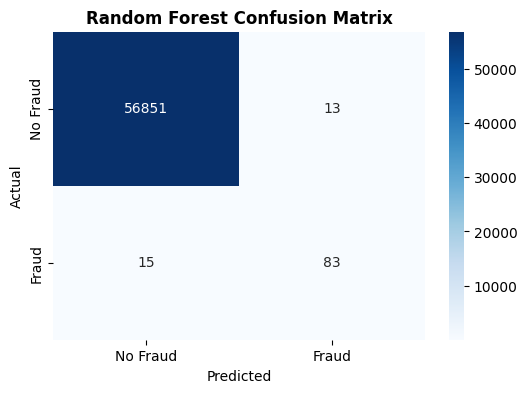

In [31]:
# Random Forest Confusion Matrix

cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='Blues', xticklabels= ['No Fraud', 'Fraud'], yticklabels= ['No Fraud', 'Fraud'])
plt.title("Random Forest Confusion Matrix", weight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Out of 98 fraud cases in the test set the model correctly caught 83 
and missed 15. The 13 false alarms are normal transactions incorrectly 
flagged as fraud — annoying for customers but less dangerous than 
missing real fraud.

## 🚀XGBoost
> XGBoost uses gradient boosting — each tree corrects the errors of the previous one. Generally one of the strongest performers on tabular data.

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score

# Model training
xgb_model = XGBClassifier(eval_metric = 'logloss', random_state = 42, objective='binary:logistic')

# Fitting xgboost on training data
xgb_model.fit(X_train_resampled, y_train_resampled)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_xgb)
# Predict on test set
xgb_pred = xgb_model.predict(X_test)

# Evaluating metrics
xgb_recall = recall_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_pred)

# Results
print(f"XGBoost Classifier Performance:")
print(f"⏪Recall :{xgb_recall: .4f}")
print(f"🎯Precision :{xgb_precision: .4f}")
print(f"⭐F1-Score :{xgb_f1: .4f}")
print(f"Roc-Auc :{xgb_roc_auc :.4f}")
print("Sample predicted probabilities:", y_prob_xgb[:10])

XGBoost Classifier Performance:
⏪Recall : 0.8776
🎯Precision : 0.7414
⭐F1-Score : 0.8037
Roc-Auc :0.9385
Sample predicted probabilities: [3.1214836e-07 4.6877826e-08 1.6104015e-06 2.6167950e-07 1.2711640e-05
 2.5748379e-06 1.4414360e-07 2.0998885e-07 9.2981509e-06 4.8400267e-07]


In [33]:
print("Features the model is been Trained on:")
print("model features", xgb_model.feature_names_in_)

Features the model is been Trained on:
model features ['V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12' 'V13'
 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24' 'V25'
 'V26' 'V27' 'V28' 'Amount' 'Hour']


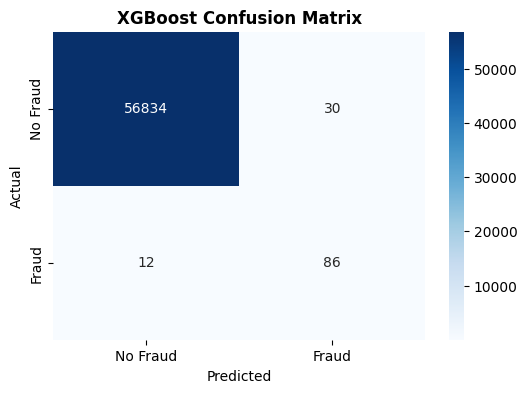

In [34]:
# XGBoost Confusion Matrix

cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='Blues', xticklabels= ['No Fraud', 'Fraud'], yticklabels= ['No Fraud', 'Fraud'])
plt.title("XGBoost Confusion Matrix", weight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Out of 98 fraud cases model catches 86 fraud and misses 12 fraud which is small improvement from above model. But it cost the model to generate the false alarm (30) on real customers which is high it can make customers irritate. 

## ⚡Lightgbm
> LightGBM is similar to XGBoost but trains significantly faster on large datasets using histogram-based splitting. We will optimize it directly for AUC since that's our primary concern here.

In [35]:
from lightgbm import LGBMClassifier

gbm_model = LGBMClassifier(objective='binary', metric = 'AUC', verbose = -1)

gbm_model.fit(X_train_resampled, y_train_resampled)
gbm_proba = gbm_model.predict_proba(X_test)[:,1]
roc_auc_gbm = roc_auc_score(y_test,gbm_proba)

gbm_pred = gbm_model.predict(X_test)

gbm_recall = recall_score(y_test, gbm_pred)
gbm_precision = precision_score(y_test, gbm_pred)
gbm_f1 = f1_score(y_test, gbm_pred)
gbm_roc_auc = roc_auc_score(y_test, gbm_pred)

print(f"Lightgbm Classifier Performance:")
print(f"Recall :{gbm_recall: .4f}")
print(f"Precision :{gbm_precision:.4f}")
print(f"F1-score :{gbm_f1: .4f}")
print(f"Roc-Auc :{gbm_roc_auc: .4f}")
print(f"sample probabilties:", gbm_proba)

Lightgbm Classifier Performance:
Recall : 0.8673
Precision :0.5215
F1-score : 0.6513
Roc-Auc : 0.9330
sample probabilties: [3.40792599e-04 3.39105544e-04 9.45303662e-04 ... 9.52778496e-05
 2.55731020e-04 4.77311475e-04]


In [36]:
print("model features:",gbm_model.feature_names_in_)

model features: ['V1' 'V2' 'V3' 'V4' 'V5' 'V6' 'V7' 'V8' 'V9' 'V10' 'V11' 'V12' 'V13'
 'V14' 'V15' 'V16' 'V17' 'V18' 'V19' 'V20' 'V21' 'V22' 'V23' 'V24' 'V25'
 'V26' 'V27' 'V28' 'Amount' 'Hour']


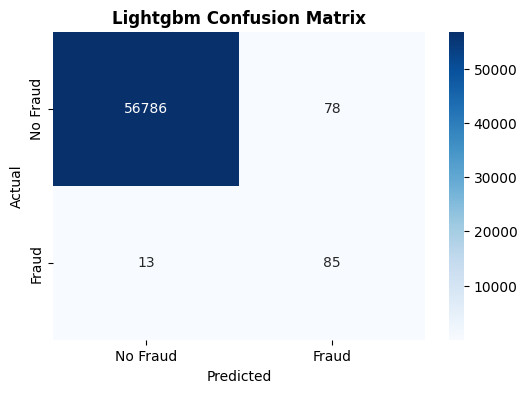

In [37]:
# Lightgbm Confusion Matrix

cm = confusion_matrix(y_test, gbm_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='Blues', xticklabels= ['No Fraud', 'Fraud'], yticklabels= ['No Fraud', 'Fraud'])
plt.title("Lightgbm Confusion Matrix", weight = 'bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🐈Catboost
> CatBoost is another gradient boosting library that tends to work well with minimal tuning. We set iterations=400 and depth=6 as a reasonable starting point.

In [38]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(iterations= 400, depth=6, verbose=0)

cat_model.fit(X_train_resampled, y_train_resampled)
cat_proba = cat_model.predict_proba(X_test)[:,1]
roc_auc_cat = roc_auc_score(y_test, cat_proba)

cat_pred = cat_model.predict(X_test)

cat_recall = recall_score(y_test,cat_pred)
cat_precision = precision_score(y_test, cat_pred)
cat_f1 = f1_score(y_test,cat_pred)
cat_roc_auc = roc_auc_score(y_test, cat_pred)

print(f"Catboost Classifier Performance:")
print(f"Recall :{cat_recall: .4f}")
print(f"Precision :{cat_precision: .4f}")
print(f"F1-Score :{cat_f1: .4f}")
print(f"Roc-Auc :{cat_roc_auc: .4f}")
print("simple probabilities:",cat_proba)

Catboost Classifier Performance:
Recall : 0.8469
Precision : 0.5845
F1-Score : 0.6917
Roc-Auc : 0.9230
simple probabilities: [1.59361242e-05 1.01490636e-10 1.90560989e-06 ... 1.43040707e-06
 3.65758451e-06 7.82676780e-05]


In [39]:
print("model features:", cat_model.n_features_in_)

model features: 30


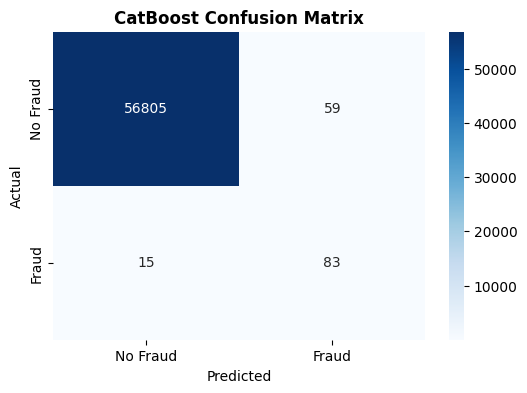

In [40]:
cm = confusion_matrix(y_test, cat_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
plt.title("CatBoost Confusion Matrix", weight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

CatBoost correctly caught 83 out of 98 fraud cases but raised 59 false alarms.This means CatBoost is being overly cautious, flagging a lot of innocent transactions as suspicious. It's catching fraud at the good rate but at the cost to legitimate customers.

## **Overall**
- XGBoost catches 3 more frauds than Random Forest but raises 17 more 
false alarms in doing so. Which model is better depends entirely on 
the business priority — minimizing financial loss (XGBoost) vs 
minimizing customer disruption (Random Forest).
- After hyperparameter tuning we'll see if this tradeoff can be improved further.

## 🛠️Hyperparameter Tuning

Baseline models use default parameters which aren't optimised for our specific dataset. We use RandomizedSearchCV with 3-fold cross-validation to search for better parameter
combinations — trying 20 random combinations rather than exhaustively testing every possible one, which would take hours.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import  RandomizedSearchCV
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Parameter grid for Random Search
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

# Randomizing Search with Cross-Validation
rf_random = RandomizedSearchCV(estimator=rf, param_distributions= param_dist, n_iter = 20, cv = 3,scoring='roc_auc', verbose = 1, random_state=42, n_jobs = -1)

# Fit on Resampled Training data
rf_random.fit(X_train_resampled, y_train_resampled)

# Best Parameters
print("Best Parameters:", rf_random.best_params_)

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))
  

Fitting 3 folds for each of 20 candidates, totalling 60 fits


# Evaluation (Test Set)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Dictionary to store results
test_results = {}

# Evaluating each model on Test set
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # As it ranges till 1


    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    
    test_results[name] = {
        "Accuracy": accuracy,
        "F1 Score": f1,
        "Roc-AUC": roc_auc
    }

    print(f"\n {name} Results:")
    print(classification_report(y_test, y_pred))

# Converting DataFrame to Dispalay
test_results_df = pd.DataFrame(test_results).T
print("\n Test Set Evaluation:")
print(test_results_df)

